# HR Employee Attrition Analysis (Over Time Attrition Rate Analysis)

**Tujuan notebook ini:** menjawab business question ke-2: Apakah overtime berkorelasi signifikan dengan attrition?

## 1. Setup & Load Data

Load data langsung dari MySQL supaya konsisten dengan sumber data yang sudah dinormalisasi.

In [1]:
# Install terlebih dahulu sqlalchemy dan pymysql untuk bisa berinteraksi dengan database
# pip install sqlalchemy pymysql
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

load_dotenv()

host = os.environ.get("DB_HOST")
user = os.environ.get("DB_USER")
password = os.environ.get("DB_PASSWORD")
database = os.environ.get("DB_NAME")

url_connect = f"mysql+pymysql://{user}:{password}@{host}/{database}"

engine = create_engine(url_connect)

In [2]:
query = "SELECT over_time, attrition FROM employees"

with engine.connect() as koneksi:
    df = pd.read_sql(query, con=koneksi)

In [3]:
print(f"Jumlah baris & kolom: {df.shape}")
df.head()

Jumlah baris & kolom: (1470, 2)


,over_time,attrition
0,Yes,Yes
1,No,No
2,Yes,Yes
3,Yes,No
4,No,No


## 2. Analisis Deskriptif Sederhana

Lakukan analisis deskriptif sederhana untuk mengetahui hubungan antara overtime dengan attrition.

In [4]:
# Mengetahui hubungan antara overtime dengan attrition menggunakan crosstab
crosstab = pd.crosstab(df['over_time'], df['attrition'])
crosstab

attrition,No,Yes
over_time,,
No,944,110
Yes,289,127


Dari tabel kontingensi di atas, terlihat proporsi karyawan yang keluar jauh lebih tinggi pada kelompok overtime dibanding yang tidak. Untuk melihat perbandingan yang lebih jelas, hitung attrition rate per kelompok di bawah ini.

In [5]:
# Mengetahui attrition rate per kelompok overtime
attrition_encoding = {'Yes': 1, 'No': 0}
df['attrition_map'] = df['attrition'].map(attrition_encoding)
attrition_over_rate = df.groupby('over_time').agg(
    jumlah_karyawan = ('attrition', 'count'),
    karyawan_keluar = ('attrition_map', 'sum'),
    attrition_over_rate_pct = ('attrition_map', lambda x: round(x.mean() * 100, 2))
)
attrition_over_rate

,jumlah_karyawan,karyawan_keluar,attrition_over_rate_pct
over_time,,,
No,1054,110,10.44
Yes,416,127,30.53


Karyawan yang **overtime** memiliki attrition rate sebesar **30,53%**, hampir 3 kali lipat dibanding karyawan yang tidak overtime (**10,44%**). Perbedaan yang cukup besar ini perlu diuji lebih lanjut apakah signifikan secara statistik atau hanya kebetulan dari variasi sampel.

## 3. Uji Statistik

Menguji tingkat asosiasi antara dua variabel kategorikal menggunakan Chi-Square Test of Independence.

In [6]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(crosstab)

print(f"Nilai Chi-square: {chi2_stat:.4f}")
if p_value < 0.0001:
    print("P-value < 0.0001")
else:
    print(f"P-value: {p_value:.4f}")
print(f"Degree of Freedom: {dof}")
print("Frekuensi Harapan (Expected):\n", expected)

if p_value < 0.05:
    print("Perbedaannya SIGNIFIKAN secara statistik")
else:
    print("Perbedaannya TIDAK signifikan secara statistik")

Nilai Chi-square: 87.5643
P-value < 0.0001
Degree of Freedom: 1
Frekuensi Harapan (Expected):
 [[884.06938776 169.93061224]
 [348.93061224  67.06938776]]
Perbedaannya SIGNIFIKAN secara statistik


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara overtime dan attrition. Selanjutnya, menghitung seberapa kuat hubungan antara kedua variabel tersebut menggunakan rumus Cramer's V.

In [7]:
# Menggunakan Cramer's V untuk mengetahui seberapa kuat asosiasi antar variabel
N = crosstab.sum().sum()
k = min(crosstab.shape)

cramers_v = np.sqrt(chi2_stat / (N * (k - 1)))
print(f"Nilai Cramer's V: {cramers_v:.4f}")

Nilai Cramer's V: 0.2441


Nilai Cramer's V sebesar 0,2441 menunjukkan tingkat asosiasi yang **antara lemah hingga sedang**. Artinya, overtime cukup berarti untuk diperhatikan sebagai salah satu faktor yang berasosiasi dengan attrition, namun bukan faktor tunggal yang paling dominan.

## 4. Visualisasi

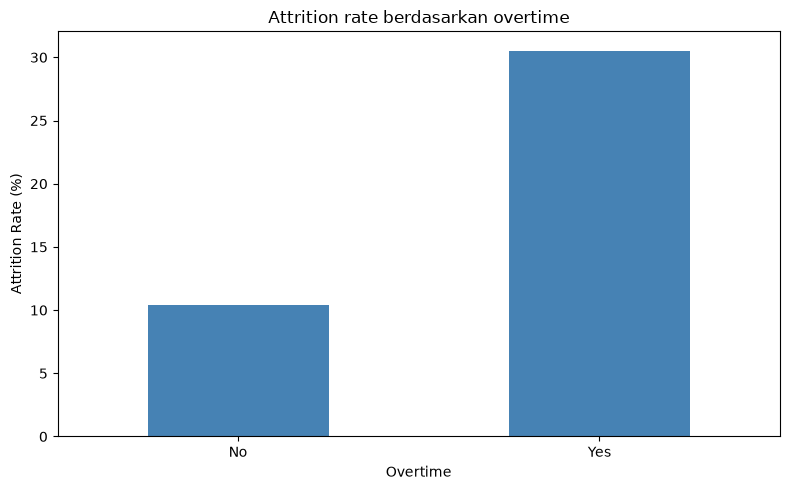

In [8]:
subset_aor = attrition_over_rate['attrition_over_rate_pct']

plt.figure(figsize=(8, 5))
subset_aor.plot(kind='bar', color='steelblue')
plt.title('Attrition rate berdasarkan overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Kesimpulan

Dari 1.470 karyawan dengan attrition rate keseluruhan sebesar 16,12%, terlihat perbedaan yang cukup besar antara karyawan yang lembur dan yang tidak. Karyawan yang **overtime** memiliki attrition rate **30,53%** (127 dari 416 orang), hampir **3 kali lipat** dibanding karyawan yang tidak overtime, yang attrition rate-nya hanya **10,44%** (110 dari 1.054 orang).

Hasil **Chi-Square Test of Independence** mengonfirmasi bahwa perbedaan ini bukan kebetulan (chi-square = 87,56, df = 1, p-value < 0,0001), sehingga terdapat asosiasi yang **signifikan secara statistik** antara overtime dan attrition. Namun, nilai **Cramér's V sebesar 0,2441** — mendekati namun belum mencapai ambang batas moderate (0,30, menurut pedoman Cohen, 1988) untuk tabel 2×2 — menunjukkan kekuatan asosiasi berada di kategori **antara lemah hingga sedang**. Artinya, overtime cukup berarti untuk diperhatikan sebagai salah satu faktor yang berasosiasi dengan attrition, namun bukan faktor tunggal yang paling dominan.

**Catatan batasan**: karena dataset ini bersifat cross-sectional (potret satu waktu), hasil ini menunjukkan **asosiasi**, bukan hubungan sebab-akibat. Belum bisa disimpulkan bahwa overtime *menyebabkan* karyawan keluar — bisa jadi ada faktor lain yang mendasari keduanya (misalnya beban kerja tinggi yang memicu overtime sekaligus ketidakpuasan kerja).

**Implikasi praktis**: mengingat attrition rate pada kelompok overtime mencapai hampir 3x lipat kelompok non-overtime, kebijakan pengelolaan beban kerja dan kompensasi lembur tetap layak dievaluasi lebih lanjut oleh HR — meskipun keputusan akhir sebaiknya juga mempertimbangkan hasil dari faktor lain (kompensasi, tenure, kepuasan kerja) di business question berikutnya, mengingat kekuatan asosiasi overtime sendiri belum tergolong dominan.